# Homework: Langevin, Metropolis, MALA, and Hamiltonian Monte Carlo

**Student:** _replace with your name_  
**Date:** _replace with the submission date_

In this project you will tune four sampling algorithms on targets with anisotropy, curvature, and multiple modes. You will use distributional error and mixing diagnostics—not visual plausibility or acceptance alone—to decide whether sampling is successful.

Restart the kernel and run all cells once before using the interactive controls.

## Project structure

The implementations intentionally live in normal Python modules:

| File | Responsibility |
|---|---|
| `mcmc_homework/targets.py` | target distributions and exact reference samplers |
| `mcmc_homework/samplers.py` | RWMH, ULA, MALA, and HMC implementations |
| `mcmc_homework/metrics.py` | sliced-Wasserstein error, ESS, and diagnostics |
| `mcmc_homework/visualization.py` | trajectory, trace, ACF, and mode-ratio plots |
| `mcmc_homework/experiments.py` | reproducible runs and repeated-seed benchmarks |
| `mcmc_homework/widgets.py` | sliders and the Start button |
| `tests/` | numerical correctness tests |

Read the implementation files alongside this notebook. The notebook is an experiment and reporting surface, not the source of every function.

## 1. Four samplers

Let $\ell(x)=\log\pi(x)$ and $Z\sim\mathcal N(0,I)$.

| Method | Transition | Hyperparameters | Correction? |
|---|---|---|---|
| **RWMH** | $Y=X_k+\sigma Z$ | proposal scale $\sigma$ | symmetric MH ratio |
| **ULA** | $X_{k+1}=X_k+\eta\nabla\ell(X_k)+\sqrt{2\eta}Z$ | step $\eta$ | none; finite-step bias |
| **MALA** | propose the ULA transition | step $\eta$ | asymmetric MH ratio |
| **HMC** | simulate position and momentum by leapfrog | integrator step $\epsilon$, number of steps $L$ | Hamiltonian MH ratio |

HMC augments the state with momentum $p\sim\mathcal N(0,I)$ and uses

$$H(x,p)=-\ell(x)+\tfrac12p^\top p.$$

A leapfrog trajectory approximately conserves $H$. The proposal is accepted with

$$\alpha=\min\{1,\exp(H(x,p)-H(x',p'))\}.$$

Small steps can waste computation; large steps can cause ULA bias/divergence or MH/HMC rejection. Large $L$ lets HMC travel farther but costs more gradients and can create resonances. No hyperparameter or acceptance target is universally best.

## 2. Targets and metrics

The core tuning tasks use:

1. a tilted ill-conditioned Gaussian;
2. a thin banana-shaped target;
3. a 65:35 bimodal mixture.

A fourth **10:90 mixture** is a guided case study about rare-mode discovery.

The primary error is standardized sliced Wasserstein-1 distance (SWD) to an exact iid reference sample. Secondary diagnostics are effective sample size (ESS), ESS per 1,000 target evaluations, acceptance, and target-specific quantities such as mode mass and switches.

### ESS: how much independent information is in the chain?

**ESS stands for Effective Sample Size.** MCMC states are usually correlated: if the chain moves slowly, $Z_{t+1}$ resembles $Z_t$ and contributes little new information. ESS translates $N$ correlated retained states into the approximate number of independent samples with the same precision for estimating a scalar summary.

For a retained scalar chain $Z_1,\ldots,Z_N$, let $\rho_k=\operatorname{Corr}(Z_t,Z_{t+k})$ be its autocorrelation at lag $k$. Then

$$\operatorname{ESS}\approx\frac{N}{\underbrace{1+2\sum_{k\geq 1}\rho_k}_{\text{integrated autocorrelation time}}}.$$

- If the states are independent, $\rho_k\approx0$ and $\operatorname{ESS}\approx N$.
- If correlations remain positive over many lags, the denominator grows and $\operatorname{ESS}\ll N$.
- For example, 5,000 retained states with $\operatorname{ESS}=200$ contain roughly the same information for that summary as 200 independent samples.

In practice the infinite sum is estimated with a stable truncation rule. ESS is feature-specific, so this notebook evaluates several features (coordinates and a target-specific global feature) and reports the minimum. A mode indicator that never changes is assigned ESS zero. To compare computational efficiency, the notebook also reports

$$\operatorname{ESS/1k}=1000\,\frac{\operatorname{ESS}}{\text{number of target evaluations}}.$$

**Higher ESS is better**, but high ESS alone does not prove that the sampled distribution is correct. A chain can move efficiently inside one mode while completely missing another mode.

### SWD: how close is the sampled distribution to the target?

**SWD stands for Sliced Wasserstein Distance.** Directly comparing two two-dimensional clouds is difficult, so SWD looks at many one-dimensional *shadows*: project both clouds onto a direction $\theta_m$, compare their projected distributions, and average over directions.

For fixed unit directions $\theta_1,\ldots,\theta_M$, the standardized score used here is

$$\operatorname{SWD}(P,Q)=\frac{1}{M}\sum_{m=1}^{M}
\frac{W_1\!\left((\theta_m^\top)_\#P,(\theta_m^\top)_\#Q\right)}
{\operatorname{SD}_{Y\sim Q}(\theta_m^\top Y)},$$

where $P$ is the retained-chain distribution and $Q$ is an exact independent reference sample from the target. The one-dimensional Wasserstein distance

$$W_1(F,G)=\int_0^1\left|F^{-1}(u)-G^{-1}(u)\right|\,du$$

compares matching quantiles; intuitively, it measures how far probability mass must move to turn one projected distribution into the other. Dividing by the target standard deviation makes the score unitless and comparable across directions.

**Lower SWD is better.** Zero means an exact empirical match, although two finite correct samples normally have a small nonzero distance—the reported *reference noise floor*. SWD can detect incorrect means, spread, geometry, and missing or incorrectly weighted modes.

In short: **ESS measures sampling efficiency; SWD measures distributional accuracy. A good run needs both.**

### Explicit pass criterion

A target–method row passes only when **the worst SWD over benchmark ensembles with base seeds `(11, 23, 47)` is at or below the target threshold** and no ensemble diverges:

| target | required worst-repeat SWD |
|---|---:|
| tilted Gaussian | $\leq 0.06$ |
| banana | $\leq 0.115$ |
| 65:35 mixture | $\leq 0.15$ |

The numerical requirement is **PASS on all 12 core target–method rows**. Completing the homework also requires the six controlled investigations below, including your own screenshots and explanations. A passing table alone is not a complete submission. Every row receives the same total budget of **40,000 target evaluations per benchmark ensemble**, including burn-in and divided across all student-selected chains. One call to $\log\pi$ and one call to $\nabla\log\pi$ each count as one evaluation. Reference sampling, plotting, and metric calculations do not consume this sampling budget.

### What students tune for the submitted benchmark

Tune a separate setting for every target–method row:

| method | method-specific quantities | meaning |
|---|---|---|
| RWMH | proposal scale $\sigma$ | standard deviation of the Gaussian random-walk proposal |
| ULA | step size $\eta$ | strength of both the gradient drift and Langevin noise step |
| MALA | step size $\eta$ | scale of the Langevin proposal before MH correction |
| HMC | integrator step $\epsilon$ and leapfrog count $L$ | numerical step size and trajectory length/cost |

**Every row also tunes:** the number of independent chains $C\in\{1,\ldots,8\}$ and a burn-in fraction between 5% and 40%. This produces 12 submitted configurations: four methods for each of three core targets. RWMH, ULA, and MALA therefore have three tuned quantities per row; HMC has four.

### The resource-allocation trade-off

The 40,000-evaluation budget is split as evenly as possible across the chosen $C$ chains. The sampler automatically runs the longest chains that fit their shares. Approximate work per transition is:

| method | work per transition | approximate total transitions across all chains |
|---|---:|---:|
| RWMH | 1 density call | $40{,}000$ |
| ULA | 1 gradient call | $40{,}000$ |
| MALA | 1 density + 1 gradient call | $20{,}000$ |
| HMC | 1 density + $L$ gradient calls | $40{,}000/(L+1)$ |

Thus, more chains create more independent attempts to explore the target but make every chain shorter and repeat the warm-up cost. More burn-in may reduce initialization bias but leaves fewer retained samples. Increasing HMC's $L$ lengthens each trajectory but reduces the number of HMC transitions. These trade-offs are part of the homework.

The official evaluation repeats the **entire $C$-chain ensemble** three times using base seeds `(11, 23, 47)`. Within a repeat with base seed $s$, chain $j=0,\ldots,C-1$ uses seed $s+101j$. All chains start from the supplied target start. Retained draws are combined for SWD; ESS and mode switches are calculated within each chain before aggregation, so chain boundaries are never counted as transitions.

**Students may not change:** the 40,000-evaluation budget, the three benchmark base seeds, initial states, evaluation accounting, or SWD thresholds.

Burn-in removes an initial transient. It cannot fix discretization bias, mode trapping, or a poorly tuned integrator.

In [1]:
# %pip install -r requirements.txt
%matplotlib inline

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sys
from IPython.display import HTML, display

# The homework package may have changed while this notebook kernel
# remained open. Remove cached local modules before importing the
# current project API so rerunning this cell is sufficient.
for module_name in tuple(sys.modules):
    if module_name == "mcmc_homework" or module_name.startswith("mcmc_homework."):
        del sys.modules[module_name]

from mcmc_homework import (
    BENCHMARK_SEEDS,
    BENCHMARK_TARGET_EVAL_BUDGET,
    CORE_TARGET_KEYS,
    DEFAULT_SETTINGS,
    METHODS,
    SWD_PASS_THRESHOLDS,
    TARGETS,
    benchmark_all_settings,
    benchmark_results_html,
    benchmark_setting,
    build_sampling_lab,
    gradient_check_report,
    metrics_html,
    plot_mode_ratio_comparison,
    plot_sampling_run,
    plot_swd_convergence,
    run_experiment,
)

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.18})

### Numerical implementation check

In [3]:
gradient_checks = gradient_check_report()
assert all(row["passed"] for row in gradient_checks), gradient_checks
display(HTML(
    "<table><tr><th>target</th><th>maximum gradient error</th><th>status</th></tr>"
    + "".join(
        f"<tr><td>{row['target']}</td><td>{row['max_abs_error']:.2e}</td><td>pass</td></tr>"
        for row in gradient_checks
    )
    + "</table>"
))

target,maximum gradient error,status
gaussian,7.96e-10,pass
banana,1.43e-10,pass
mixture,7.49e-10,pass
imbalanced_mixture,2.34e-10,pass


## 3. Read an HMC diagnostic plot

Orange is the burn-in path; blue points are retained states. The trace panel shows $x_1$ and $x_2$ over transitions. Running statistics expose slow convergence, and the ACF panel shows correlation among retained states.

This is a demonstration setting, not an answer key for the final fixed-budget benchmark.

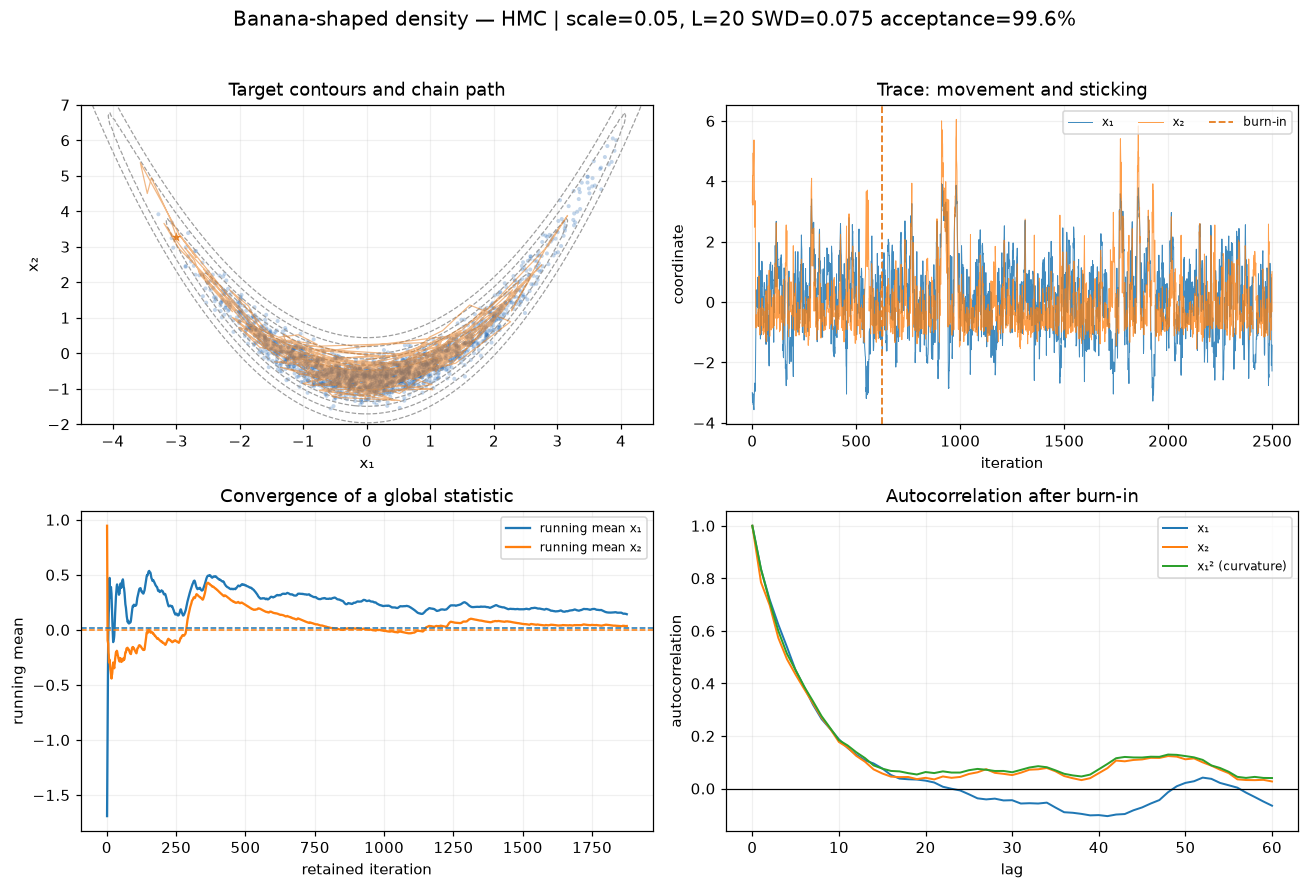

Metric,Value
Single plotted chain: SWD (lower is better),0.075
"Official worst-repeat SWD target (base seeds 11, 23, 47)",≤ 0.115
Reference-sample SWD noise floor,≈ 0.030
Minimum ESS after burn-in,81.5
"Minimum ESS per 1,000 target evaluations",1.6
Acceptance rate,99.6%
residual-scale error,0.017
x₁ variance error,0.043


In [4]:
hmc_demo = run_experiment(
    "banana", "HMC", scale=0.05,
    n_steps=2500, burn_fraction=0.25, seed=11, n_leapfrog=20,
)
plot_sampling_run(hmc_demo)
plt.show()
display(HTML(metrics_html(hmc_demo)))

## 4. Interactive tuning lab

The lab now mirrors one official benchmark ensemble. Select a target and method, tune its scale, choose burn-in and the number of chains $C$, and press **Start sampling**. HMC also exposes leapfrog count $L$. The total budget is always 40,000 target evaluations; changing $C$ or $L$ automatically changes the number of states produced by each chain.

The dashboard shows every chain path, per-chain traces, combined SWD as the budget is spent, and within-chain autocorrelation averaged across chains. The table scores all retained chains together. This lab uses base seed 11; the final benchmark repeats the same ensemble design with base seeds 11, 23, and 47.

Inspect all paths and traces before looking at SWD. Several short chains that remain in the same mode are not equivalent to genuine global exploration.

In [5]:
lab = build_sampling_lab()
display(lab.ui)

## 5. Guided case study: a rare 10% mode

Both Gaussian components have unit covariance, but the left component has probability 0.10 and the right component 0.90. Both chains start in the dominant right mode and receive the same number of transitions.

The ULA setting below is deliberately local: in this finite run it never represents the rare mode. HMC refreshes momentum, integrates longer trajectories, crosses the density barrier repeatedly, and approaches the target ratio. This illustrates a specific geometry/budget/tuning combination—not a theorem that all Langevin samplers always fail on mixtures.

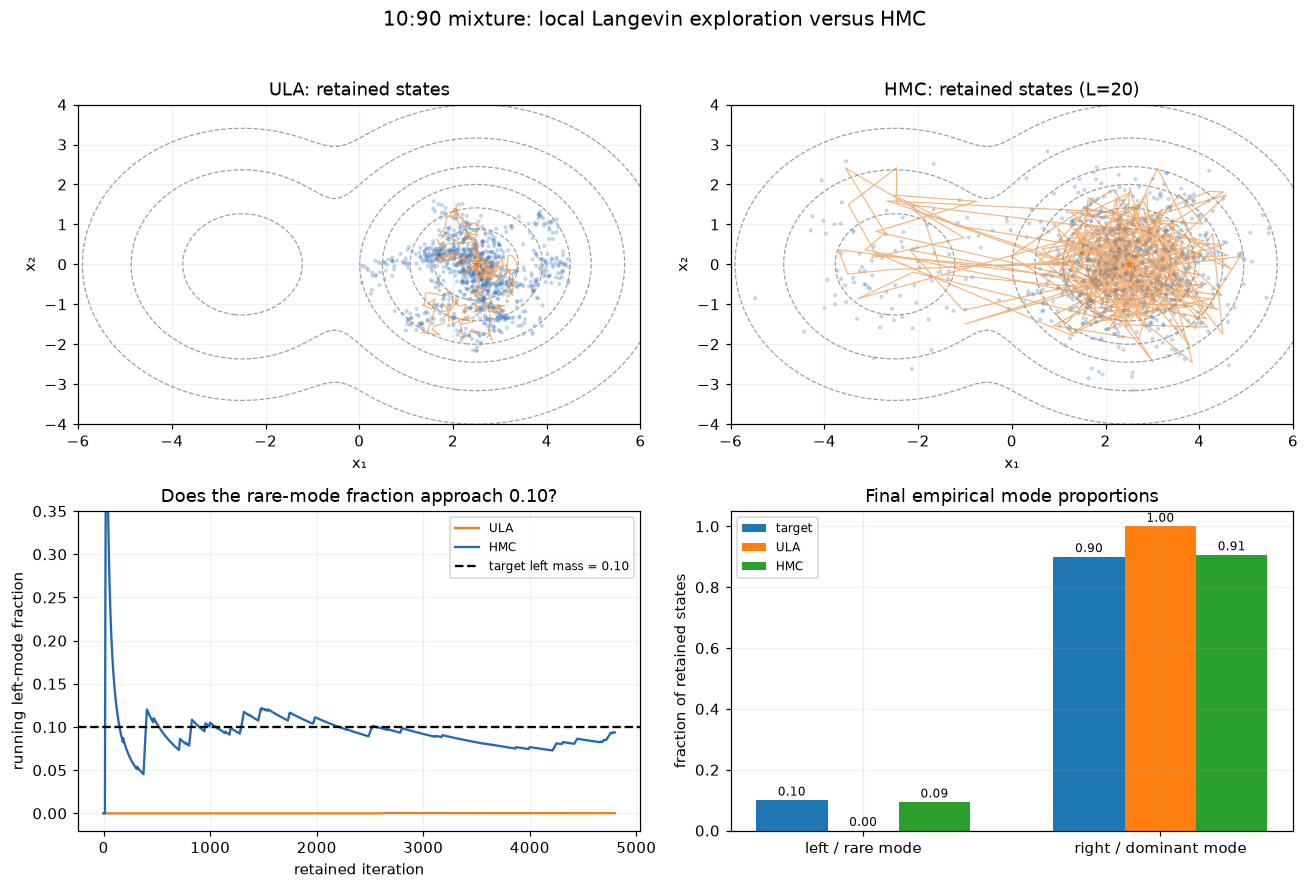

In [6]:
rare_mode_ula = run_experiment(
    "imbalanced_mixture", "ULA", scale=0.002,
    n_steps=6000, burn_fraction=0.20, seed=47,
)
rare_mode_hmc = run_experiment(
    "imbalanced_mixture", "HMC", scale=0.12,
    n_steps=6000, burn_fraction=0.20, seed=47, n_leapfrog=20,
)
plot_mode_ratio_comparison(rare_mode_ula, rare_mode_hmc)
plt.show()

**Case-study questions**

1. Report the final left:right proportions for ULA and HMC.
2. Why can a sampler produce a visually plausible cloud in the right mode while still having a large distributional error?
3. Compare the number of mode switches. Why is one transition weaker evidence than many transitions?
4. Increase ULA's step. Can it cross? If so, what happens to SWD and finite-step bias?
5. Reduce HMC's $L$ while keeping $\epsilon$ fixed. When does rare-mode discovery degrade?

**Your answer:** _replace this text._

## 6. Record and benchmark your settings

Record a justified choice for every row below. RWMH uses `scale = sigma`; ULA/MALA use `scale = eta`; HMC uses `scale = epsilon` plus `n_leapfrog = L`. The supplied values are starting guesses, not optimized answers. Keep a search log containing at least three distinct candidate configurations per row (at least 36 entries in total); report failures as well as improvements. You may search manually or with your own script.

For each candidate, record target, method, scale, $L$ if applicable, $C$, burn-in, and the measured SWD. Mark whether a score is from the lab's single base seed or from the three-repeat benchmark. Fully benchmark at least your two strongest candidates per row and report their worst-repeat SWD before selecting your final configuration. Changing a parameter is not mandatory when your experiments justify retaining its value.

For every row, choose `scale`, `n_chains`, and `burn_fraction`; HMC rows additionally choose `n_leapfrog`. Choose them separately for all three targets. Do not change the official 40,000-evaluation budget, benchmark base seeds `(11, 23, 47)`, initial states, accounting rule, or SWD thresholds. The table gives each row a direct **PASS / TUNE MORE** status. The plot shows whether worst-repeat SWD approaches and crosses the dashed requirement as the shared evaluation budget is spent. Curves need not decrease monotonically.

To check one candidate across the official repeats without rerunning all 12 rows, call `benchmark_setting(target_key, method, **candidate, seeds=BENCHMARK_SEEDS, target_eval_budget=BENCHMARK_TARGET_EVAL_BUDGET)`. Here `candidate` is a settings dictionary with the same fields as a row of `student_settings`. The returned pair is `(ensembles, summary)`; record `summary["worst_swd"]` in your log.

**Your search log and justification of the final candidates:** _insert your table here, or link to an included results file._

In [7]:
# TODO: select and justify all 12 configurations after exploration.
student_settings = {
    key: value.copy()
    for key, value in DEFAULT_SETTINGS.items()
    if key[0] in CORE_TARGET_KEYS
}
student_settings

{('gaussian', 'RWMH'): {'scale': 0.12, 'n_chains': 2, 'burn_fraction': 0.25},
 ('gaussian', 'ULA'): {'scale': 0.008, 'n_chains': 2, 'burn_fraction': 0.25},
 ('gaussian', 'MALA'): {'scale': 0.008, 'n_chains': 2, 'burn_fraction': 0.25},
 ('gaussian', 'HMC'): {'scale': 0.08,
  'n_leapfrog': 15,
  'n_chains': 2,
  'burn_fraction': 0.25},
 ('banana', 'RWMH'): {'scale': 0.18, 'n_chains': 2, 'burn_fraction': 0.25},
 ('banana', 'ULA'): {'scale': 0.002, 'n_chains': 2, 'burn_fraction': 0.25},
 ('banana', 'MALA'): {'scale': 0.003, 'n_chains': 2, 'burn_fraction': 0.25},
 ('banana', 'HMC'): {'scale': 0.05,
  'n_leapfrog': 20,
  'n_chains': 2,
  'burn_fraction': 0.25},
 ('mixture', 'RWMH'): {'scale': 0.9, 'n_chains': 2, 'burn_fraction': 0.25},
 ('mixture', 'ULA'): {'scale': 0.06, 'n_chains': 2, 'burn_fraction': 0.25},
 ('mixture', 'MALA'): {'scale': 0.08, 'n_chains': 2, 'burn_fraction': 0.25},
 ('mixture', 'HMC'): {'scale': 0.18,
  'n_leapfrog': 20,
  'n_chains': 2,
  'burn_fraction': 0.25}}

target,method,setting,mean ± SD SWD,worst / required,ESS/1k,accept,diverged,status
gaussian,RWMH,"σ=0.12; C=2, burn=25%",0.079 ± 0.054,0.142 / ≤ 0.060,1.3,75.2%,0,TUNE MORE
gaussian,ULA,"η=0.008; C=2, burn=25%",0.088 ± 0.035,0.128 / ≤ 0.060,1.7,N/A,0,TUNE MORE
gaussian,MALA,"η=0.008; C=2, burn=25%",0.169 ± 0.058,0.236 / ≤ 0.060,0.9,95.2%,0,TUNE MORE
gaussian,HMC,"ε=0.08, L=15; C=2, burn=25%",0.049 ± 0.021,0.067 / ≤ 0.060,8.5,97.5%,0,TUNE MORE
banana,RWMH,"σ=0.18; C=2, burn=25%",0.137 ± 0.034,0.165 / ≤ 0.115,1.7,73.5%,0,TUNE MORE
banana,ULA,"η=0.002; C=2, burn=25%",0.161 ± 0.037,0.193 / ≤ 0.115,0.7,N/A,0,TUNE MORE
banana,MALA,"η=0.003; C=2, burn=25%",0.223 ± 0.064,0.288 / ≤ 0.115,0.5,99.1%,0,TUNE MORE
banana,HMC,"ε=0.05, L=20; C=2, burn=25%",0.099 ± 0.058,0.162 / ≤ 0.115,2.7,99.6%,0,TUNE MORE
mixture,RWMH,"σ=0.9; C=2, burn=25%",0.149 ± 0.084,0.245 / ≤ 0.150,1.1,47.0%,0,TUNE MORE
mixture,ULA,"η=0.06; C=2, burn=25%",0.296 ± 0.236,0.449 / ≤ 0.150,0.6,N/A,0,TUNE MORE


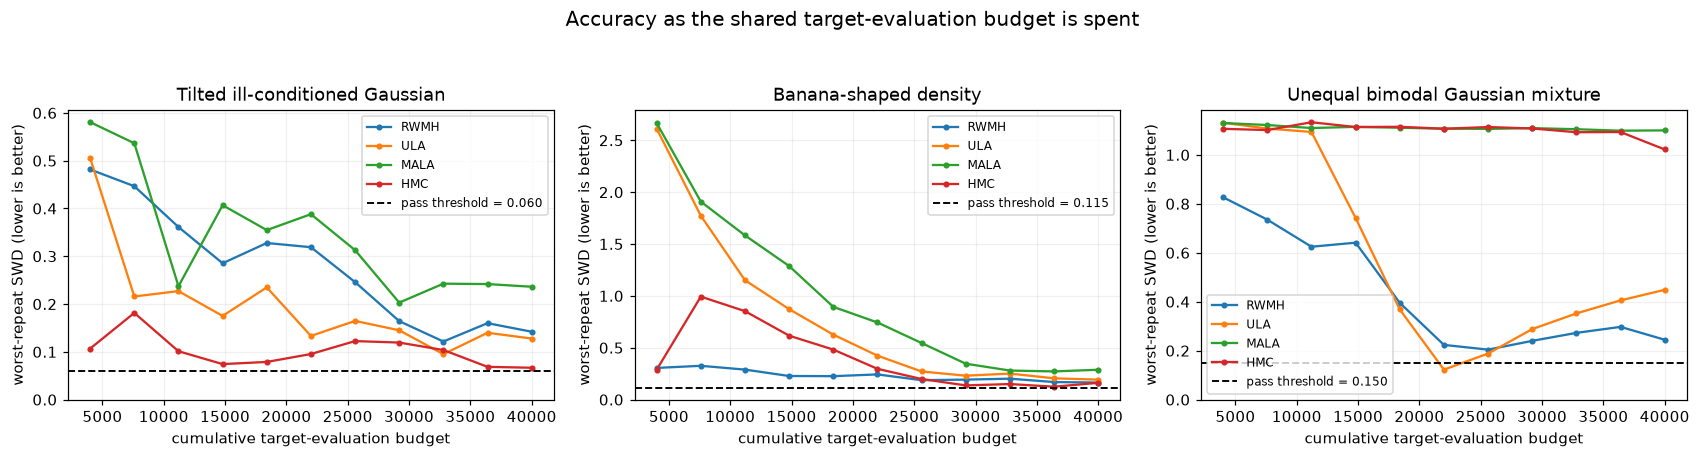

In [8]:
RUN_FULL_BENCHMARK = True  # set False only while doing quick exploration

if RUN_FULL_BENCHMARK:
    # Official submission evaluation: do not change these arguments.
    benchmark_results = benchmark_all_settings(
        student_settings,
        target_eval_budget=BENCHMARK_TARGET_EVAL_BUDGET,
        seeds=(11, 23, 47),
    )
    display(HTML(benchmark_results_html(benchmark_results)))
    plot_swd_convergence(benchmark_results)
    plt.show()
else:
    print("Set RUN_FULL_BENCHMARK = True to see the official PASS / TUNE MORE result.")

## 7. Controlled investigations: explain what the hyperparameters do

Complete all six investigations. The goal is to explain observed trade-offs using evidence, not just find settings that pass. Unless an investigation says otherwise, change **one parameter at a time** and keep the method, target, initial state, base seed 11, $C$, burn-in, and total budget fixed. The automatically derived chain length may change; record it. Use the same target-specific axes when comparing plots.

For every investigation, include a compact results table and a 100–200 word explanation connecting **parameter change → observed behaviour → measured effect**. The table should identify every setting and include SWD, ESS/1k, acceptance (N/A for ULA), states per chain, and retained states. For mixtures, also report mode-mass error and within-chain switches. Add a divergence flag; do not omit failed runs or replace them with successful seeds. Describe results that contradict your initial prediction rather than forcing an expected pattern.

**Screenshot requirement:** capture your own lab dashboard **and its metric table**, with the target, method, full settings, and budget visible or stated in the caption. Save each contrasting run before pressing Start again, because the lab replaces the previous output. Insert labelled before/after or small/large screenshots beneath the corresponding answer, with at least the evidence specified below. Several captures may be assembled into one readable comparison panel. Screenshots must show completed runs and readable axis labels and numbers.

In a Markdown answer cell, paste images as notebook attachments, or link to included files, for example `![RWMH: small proposal](screenshots/investigation-1-small.png)`. If using linked files, submit the `screenshots/` directory alongside the notebook; local absolute paths will not work on another computer. Synthetic diagrams and copies of the supplied demo are not substitutes for your experiment screenshots.

### Investigation 1 — RWMH: acceptance versus movement

On both the tilted Gaussian and the 65:35 mixture, test at least three proposal scales $\sigma$: small, intermediate, and large. Keep $C$ and burn-in fixed within each target. Choose a range wide enough to reveal different behaviour, then refine it if necessary.

Explain how acceptance, repeated states, distance travelled, and autocorrelation change. Can very high acceptance coexist with poor SWD or ESS? Why does a scale that traverses the Gaussian's long axis also cause rejection across its narrow axis? On the mixture, does a larger proposal discover the other mode more often, and at what cost?

**Evidence:** screenshot the small- and large-scale runs on each target (four captures, which may be arranged into two panels). Include all six or more runs in your results table. Explain your preferred compromise for each geometry.

**Your results table, screenshots with captions, and explanation:** _replace this text._

### Investigation 2 — ULA: slow exploration, discretization bias, and instability

On the Gaussian and banana targets, compare a small, intermediate, and large step $\eta$, keeping $C$ and burn-in fixed. Look for a stable but slowly exploring run, a useful compromise, and a large-step run with distorted shape or divergence. If a run diverges, record that outcome and try a nearby smaller step to examine the stable regime.

Use traces and ACF to discuss mixing, and covariance error (Gaussian) or residual-scale error (banana) to discuss shape. Why can a step with larger ESS still have worse SWD? Explain the simultaneous changes in gradient drift and noise amplitude $\sqrt{2\eta}$. For the Gaussian, derive $\eta<2\lambda_{\min}(\Sigma)$ from the linear update and relate this stability condition to your observations. Stability alone does not imply accurate sampling. Do not attribute every single-run error to discretization bias; state what your evidence can distinguish from finite-sample error.

**Evidence:** screenshot the small- and large-step runs on each target (four captures). If the large step diverges, include the warning. Include the intermediate settings in the results table.

**Your results table, screenshots with captions, and explanation:** _replace this text._

### Investigation 3 — MALA: what the Metropolis correction changes

On the banana, run ULA and MALA at the same three step sizes: small, intermediate, and aggressive. Hold $C$, burn-in, and the 40,000-evaluation budget fixed. You may reuse ULA runs from Investigation 2 if their settings match exactly.

Explain why the two methods share a proposal but can produce different retained clouds and traces. What happens to MALA acceptance and repeated states as $\eta$ increases? Does correction automatically imply good finite-budget sampling? Compare the automatically allocated states per chain: MALA uses both density and gradient calls. Discuss accuracy and efficiency together when choosing between the two methods.

**Evidence:** place screenshots of ULA and MALA at the same aggressive step side by side (two captures). Report all six combinations in the table and identify the scale at which correction most visibly changes behaviour.

**Your results table, screenshots with captions, and explanation:** _replace this text._

### Investigation 4 — HMC: short versus long trajectories

On both the banana and the 65:35 mixture, compare a small $L$ (1–3), an intermediate $L$ (8–15), and a large $L$ (25–40). Keep $\epsilon$, $C$, and burn-in fixed within each target. These ranges define contrasts, not recommended optima. Record trajectory duration $T=\epsilon L$, states per chain, acceptance, SWD, and ESS/1k.

Explain whether longer trajectories travel farther or switch modes more often, and whether that benefit compensates for fewer proposals under the fixed budget. Do you observe wasted travel, rejection, or a trajectory returning near its starting point? Increasing $L$ is not guaranteed to help: explain your actual observations on both geometries.

Next, on one of those targets, hold $L$, $C$, and burn-in fixed and compare small versus large $\epsilon$. Explain how changing integration accuracy differs from changing $L$. Distinguish leapfrog steps inside a proposal from retained MCMC states.

**Evidence:** screenshot low and high $L$ on each target (four captures), plus the small/large $\epsilon$ comparison (two captures). Record intermediate runs in the table. Justify your final $(\epsilon,L)$ jointly.

**Your results table, screenshots with captions, and explanation:** _replace this text._

### Investigation 5 — Chain count: independent restarts versus chain length

Compare $C=1,2,4,8$ for ULA and HMC on both the Gaussian and the 65:35 mixture. For each target–method pair, hold scale, $L$ where applicable, and burn-in fixed. The total budget remains 40,000 across all chains. List states and retained states per chain as $C$ changes.

Explain how independent restarts and shorter within-chain exploration compete. At a fixed burn-in fraction, the total fraction of work discarded is approximately unchanged; the difficulty is that each shorter chain must still escape its initial transient. All chains start from the same supplied point: why can many trapped chains still miss a mixture mode? Compare pooled SWD with the individual traces and mode switches. Use the three benchmark base seeds to check whether the apparent benefit of your preferred $C$ survives repetition.

**Evidence:** screenshot $C=1$ and $C=8$ for at least two contrasting target–method pairs (four captures, showing all chain traces). Include the full four-pair sweep in the table and explain any differences between methods or geometries.

**Your results table, screenshots with captions, and explanation:** _replace this text._

### Investigation 6 — Burn-in and the reliability of your final choice

Choose two contrasting target–method pairs from your earlier experiments. For each, compare 5%, 20%, and 40% burn-in while keeping every other setting fixed. With the same base seed the generated paths should be identical: only the portion retained for scoring changes. Report retained counts, SWD, ESS/1k, and any initial transient visible in the traces.

Explain when discarding more states improves accuracy and when it loses useful information. Does extra burn-in resolve a missing mode or ULA's finite-step bias? If your two cases behave similarly, say so and support that conclusion rather than inventing a contrast.

**Evidence:** screenshot low versus high burn-in for both pairs (four captures). Then include your final **12/12 PASS** benchmark table and SWD-versus-budget figure, with your completed search log from Section 6. Discuss at least one setting that looked attractive in the lab but was worse across the benchmark repeats; if none did, compare the measured gaps for your two strongest candidates. Explain why these finite-run pass marks do not prove convergence or universal superiority of a method.

**Your results table, screenshots with captions, and explanation:** _replace this text._

## Submission checklist

- [ ] I inspected the separate implementation modules.
- [ ] I tuned method scale, chain count, and burn-in for all 12 rows; I also tuned $L$ for HMC.
- [ ] I ran the unchanged 40,000-evaluation benchmark with all three fixed base seeds.
- [ ] Every row in the benchmark table says **PASS** (12/12).
- [ ] I reported mean $\pm$ SD and worst-repeat SWD.
- [ ] My search log contains at least three candidates per row, including full benchmarks for the two strongest.
- [ ] I interpreted the SWD-over-target-evaluation-budget figure.
- [ ] I interpreted acceptance, ESS/target-evaluation cost, and task diagnostics.
- [ ] I completed the 10:90 rare-mode case-study questions.
- [ ] I completed all six controlled investigations with results tables and explanations.
- [ ] I inserted my own labelled screenshots for every requested comparison, including unsuccessful runs.
- [ ] My images are embedded as attachments or included in a portable `screenshots/` directory.
- [ ] I included the final benchmark table and convergence figure, then restarted the kernel and ran all cells before submission.